In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patheffects as pe

base_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\6WA"
analytical_folder = "F:\\Projects\\EMGeoInversion\\Tests_Thesis\\semi-analytic_100MHz"
postprocess_folder = os.path.join(base_folder, "postprocess")

## Wholespace Decays

In [2]:
def receiver_line_plot(datasets, quantities, postprocess_folder, fname, orientation='Endfire',
                    suptitle=None, color_list=None):
    # Styling constants
    font_suptitle = 24
    font_label    = 18
    font_tick     = 18
    font_legend   = 15
    normal_lw     = 2.0

    # Analytical curves (draw first, underneath)
    fixed_styles = {
        'Analytical Solution': {
            'color':    '#000000',
            'linestyle':'-',
            'linewidth': normal_lw * 1.5,
            'zorder':   1
        },
        'empymod - 2001 DLF': {
            'color':    '#008000',  # green
            'linestyle':'--',
            'linewidth': normal_lw * 1.5,
            'zorder':   1
        }
    }

    # Build variable source list preserving order
    all_sources = []
    seen = set()
    for ds in datasets:
        src = ds[6]
        if src not in seen:
            all_sources.append(src)
            seen.add(src)
    variable_sources = [s for s in all_sources if s not in fixed_styles]

    # High-impact, colorblind-safe palette
    palette = [
    "#1f77b4",  # Blue
    "#d62728",  # Red
    "#2ca02c",  # Green
    "#e66100",  # Carrot Orange (improved)
    "#17becf",  # Teal
    "#9467bd",  # Purple
    "#bcbd22",  # Yellow-Green
    "#1fa2ff",  # Sky Blue
    "#ff6f61",  # Coral
    "#40e0d0",  # Turquoise
    ]

    # Linestyle cycle
    linestyles = [
        '--',         # dashed
        ':',          # dotted
        '-.',         # dash-dot
        (0, (3, 1, 1, 1)),  # dash-dot pattern
        (0, (5, 1)),  # long dash, short gap
        (0, (1, 1)),  # dense dots
    ]
    
    # Assign colors and styles to variable sources
    origin_styles = {**fixed_styles}
    for idx, src in enumerate(variable_sources):
        color = palette[color_list[idx] % len(palette)] if color_list else palette[idx % len(palette)]
        ls = linestyles[idx % len(linestyles)]
        origin_styles[src] = {
            'color':     color,
            'linestyle': ls,
            'linewidth': normal_lw,
            'alpha':     1.0,
            'zorder':    3 + idx
        }

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for j, (title, ylabel) in enumerate(quantities):
        ax = axes[j//2, j%2]

        # Plot analytical curves
        for src, style in fixed_styles.items():
            try:
                ds = next(d for d in datasets if d[6] == src)
            except StopIteration:
                continue
            y = [ds[0], ds[1], ds[2], ds[3]][j]
            x = ds[5]
            plot_fn = ax.semilogy if j == 0 else ax.plot
            ln, = plot_fn(x, y,
                            label=src,
                          color=style['color'],
                          linestyle=style['linestyle'],
                          linewidth=style['linewidth'],
                          zorder=style['zorder'])
            ln.set_path_effects([
                pe.Stroke(linewidth=style['linewidth']+2, foreground='white'),
                pe.Normal()
            ])

        # Plot variable curves
        for ds in datasets:
            src = ds[6]
            if src in fixed_styles:
                continue
            y = [ds[0], ds[1], ds[2], ds[3]][j]
            x = ds[5]
            style = origin_styles[src]
            plot_fn = ax.semilogy if j == 0 else ax.plot
            plot_fn(x, y,
                    label=src,
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth']*0.8,
                    alpha=style['alpha'],
                    zorder=style['zorder'])

        # Grid, labels, legend
        ax.grid(True, which='both' if j == 0 else 'major', linestyle='--', linewidth=0.5)
        ax.set_title(title, fontsize=font_label, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=font_label)
        if j//2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if j == 3:
            ax.legend(fontsize=font_legend, loc='lower right')

    # Suptitle & save
    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    print(f"Saved plot to {os.path.join(postprocess_folder, fname)}")
    plt.show()


In [3]:
def compute_errors(ref, elfe):
    errors = []
    for idx in range(4):  # amp, phase, real, imag
        ref_data = ref[idx]
        elfe_data = elfe[idx]
        if idx in [0, 2, 3]:
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
                err[~np.isfinite(err)] = np.nan
        else:
            err = elfe_data - ref_data
        errors.append(err)
    errors.append(elfe[5])
    return tuple(errors)

In [8]:
def receiver_line_error_plot(datasets, reference_dataset, quantities, postprocess_folder, fname, orientation='Endfire',
                             suptitle=None, color_list=None):
    # Styling constants
    font_suptitle = 24
    font_label    = 18
    font_tick     = 18
    font_legend   = 15
    normal_lw     = 2.0

    # Analytical curves (draw first, underneath)
    fixed_styles = {
        'Analytical Solution': {
            'color':    '#000000',
            'linestyle':'-',
            'linewidth': normal_lw * 1.5,
            'zorder':   1
        },
        'empymod - 2001 DLF': {
            'color':    '#008000',  # green
            'linestyle':'--',
            'linewidth': normal_lw * 1.5,
            'zorder':   1
        }
    }

    # Build variable source list preserving order
    all_sources = []
    seen = set()
    for ds in datasets:
        src = ds[6]
        if src not in seen:
            all_sources.append(src)
            seen.add(src)
    variable_sources = [s for s in all_sources if s not in fixed_styles]

    # High-impact, colorblind-safe palette
    palette = [
    "#1f77b4",  # Blue
    "#d62728",  # Red
    "#2ca02c",  # Green
    "#e66100",  # Carrot Orange (improved)
    "#17becf",  # Teal
    "#9467bd",  # Purple
    "#bcbd22",  # Yellow-Green
    "#1fa2ff",  # Sky Blue
    "#ff6f61",  # Coral
    "#40e0d0",  # Turquoise
    ]

    # Linestyle cycle
    linestyles = [
        '--',         # dashed
        ':',          # dotted
        '-.',         # dash-dot
        (0, (3, 1, 1, 1)),  # dash-dot pattern
        (0, (5, 1)),  # long dash, short gap
        (0, (1, 1)),  # dense dots
    ]
    
    # Assign colors and styles to variable sources
    origin_styles = {**fixed_styles}
    for idx, src in enumerate(variable_sources):
        color = palette[color_list[idx] % len(palette)] if color_list else palette[idx % len(palette)]
        ls = linestyles[idx % len(linestyles)]
        origin_styles[src] = {
            'color':     color,
            'linestyle': ls,
            'linewidth': normal_lw,
            'alpha':     1.0,
            'zorder':    3 + idx
        }

    # Compute amplitude error range for ylims
    amp_errors = []
    for ds in datasets:
        src = ds[6]
        if src in fixed_styles:
            continue
        ref_data = reference_dataset[0]
        elfe_data = ds[0]
        with np.errstate(divide='ignore', invalid='ignore'):
            err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
            err[~np.isfinite(err)] = np.nan
        amp_errors.append(err)
    amp_errors = np.array(amp_errors)
    amp_min = np.nanmin(amp_errors)
    amp_max = np.nanmax(amp_errors)

    # Plotting
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    for j, (title, ylabel) in enumerate(quantities):
        ax = axes[j//2, j%2]

        # Plot errors for variable curves
        for ds in datasets:
            src = ds[6]
            if src in fixed_styles:
                continue
            ref_data = reference_dataset[j]
            elfe_data = ds[j]
            if j in [0, 2, 3]:
                with np.errstate(divide='ignore', invalid='ignore'):
                    err = np.abs(elfe_data - ref_data) / np.abs(ref_data)
                    err[~np.isfinite(err)] = np.nan
                ax.set_title(f"Normalized Error in {title}", fontsize=font_label, fontweight='bold')
            else:
                err = elfe_data - ref_data
                ax.set_title(f"Error in {title}", fontsize=font_label, fontweight='bold')
            x = ds[5]
            style = origin_styles[src]
            plot_fn = ax.semilogy if j != 1 else ax.plot
            plot_fn(x, err,
                    label=f"{src}",
                    color=style['color'],
                    linestyle=style['linestyle'],
                    linewidth=style['linewidth']*0.8,
                    alpha=style['alpha'],
                    zorder=style['zorder'])
        ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
        ax.grid(True, which='both' if j != 1 else 'major', linestyle='--', linewidth=0.5)
        ax.set_ylabel('Error', fontsize=font_label)
        if j//2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)
        if j == 1:
            ax.legend(fontsize=font_legend, loc='upper left')
        # Set ylims for all except phase plot (assume phase is index 1)
        if j != 1:
            ax.set_ylim(amp_min, amp_max)

    # Suptitle & save
    fig.suptitle(suptitle, fontsize=font_suptitle, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
    plt.show()


In [9]:
analytical_file = os.path.join(analytical_folder, "Exx_single_freq_air_100MHz.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_evert = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Analytical Solution'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Analytical Solution'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Analytical Solution')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

electric_file = os.path.join(base_folder, "out_WA_l2_PML_Simple", "electric_fields_receiver_line.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l2_PML_Exp", "electric_fields_receiver_line.txt")
e_data_elfe_3 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l2_PML_Poly", "electric_fields_receiver_line.txt")
e_data_elfe_4 = np.loadtxt(electric_file)

e_data_elfe_all = [e_data_elfe_1, e_data_elfe_3, e_data_elfe_4]

labels = [
    r'Exact Reciprocal Decay',
    r'Exponential Decay',
    r'Polynomial Decay'
    ]

# Allow custom number of receivers for each data set
num_rec_ef_list = [256] * len(e_data_elfe_all)
num_rec_bs_list = [256] * len(e_data_elfe_all)
num_rec_ob_list = [256] * len(e_data_elfe_all)

dataset_elfe_4 = []
for i, e_data_elfe in enumerate(e_data_elfe_all):
    num_rec_ef = num_rec_ef_list[i]

    rec_x_elfe = e_data_elfe[:, 0]
    rec_y_elfe = e_data_elfe[:, 1]
    real_Ex_elfe = e_data_elfe[:, 4]
    imag_Ex_elfe = e_data_elfe[:, 5]
    abs_Ex_elfe = np.abs(real_Ex_elfe + 1j * imag_Ex_elfe)
    phase_Ex_elfe = np.angle(real_Ex_elfe + 1j * imag_Ex_elfe)

    # Endfire
    i_rx_ef = 0
    abs_ef = abs_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    phase_ef = phase_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    real_ef = real_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    imag_ef = imag_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    r_ef = rec_x_elfe[i_rx_ef:i_rx_ef + num_rec_ef]

    dataset_elfe_4.append((abs_ef, phase_ef, real_ef, imag_ef, 'Endfire', r_ef, labels[i]))

# Use datasets from Evert, empymod, and elfe for Endfire
datasets_4 = [ds for ds in dataset_evert if ds[4] == 'Endfire']
datasets_4 += dataset_elfe_4
orientation = 'Endfire'
fname = f"1_decays_comparison_{orientation.lower()}.png"

Saved plot to F:\Projects\EMGeoInversion\Tests_Thesis\6WA\postprocess\1_decays_comparison_endfire.png


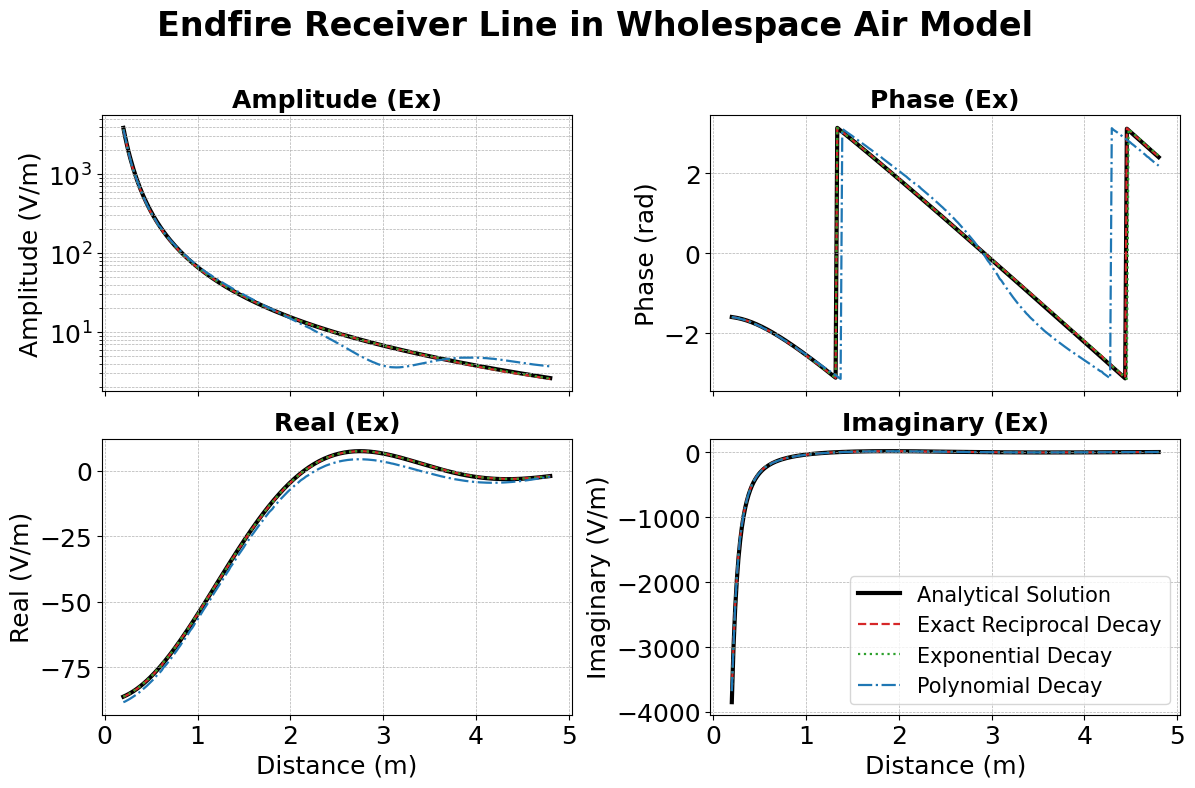

In [10]:
receiver_line_plot(datasets_4, 
                quantities, 
                postprocess_folder, 
                fname=fname, 
                orientation=orientation, 
                suptitle=f"{orientation} Receiver Line in Wholespace Air Model", 
                color_list=[1,2,0])

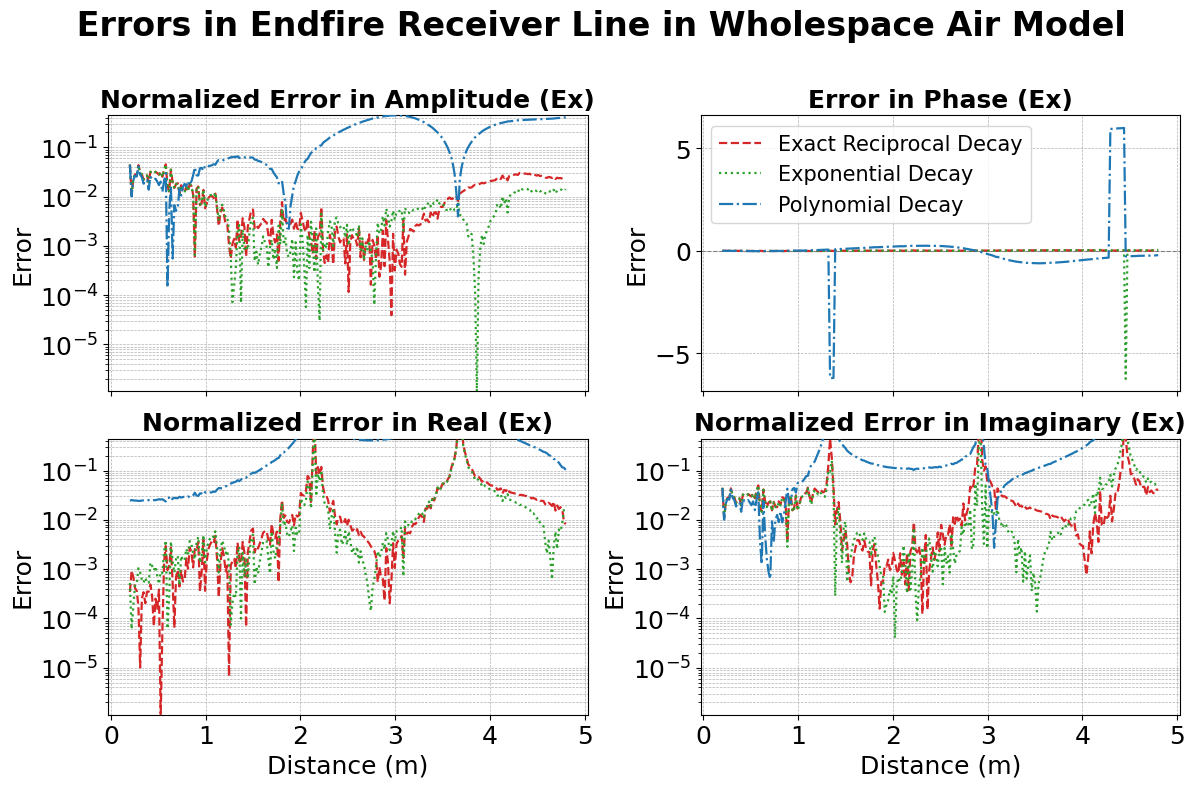

In [11]:
receiver_line_error_plot(datasets_4, 
                dataset_evert[0],  # Use Evert as reference
                quantities, 
                postprocess_folder, 
                fname=f"1_decays_comparison_{orientation.lower()}_error.png", 
                orientation=orientation, 
                suptitle=f" Errors in {orientation} Receiver Line in Wholespace Air Model", 
                color_list=[1,2,0])

## Wholespace z

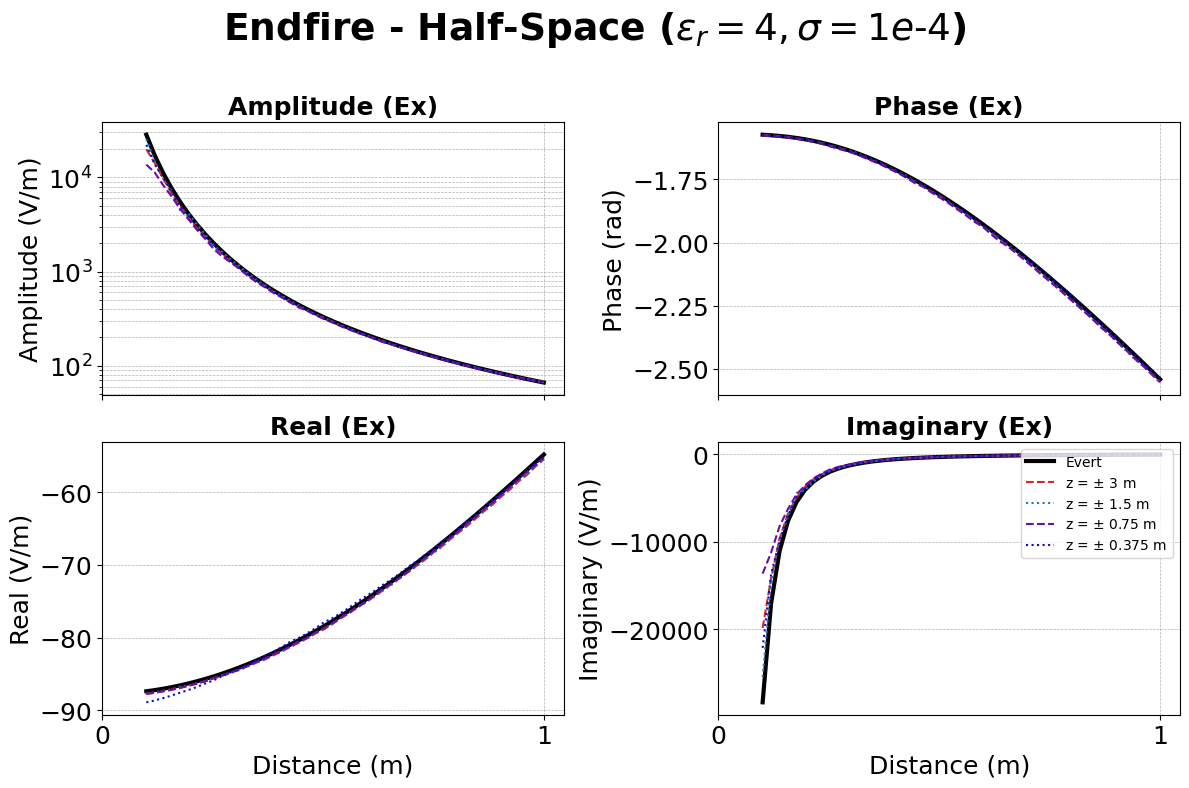

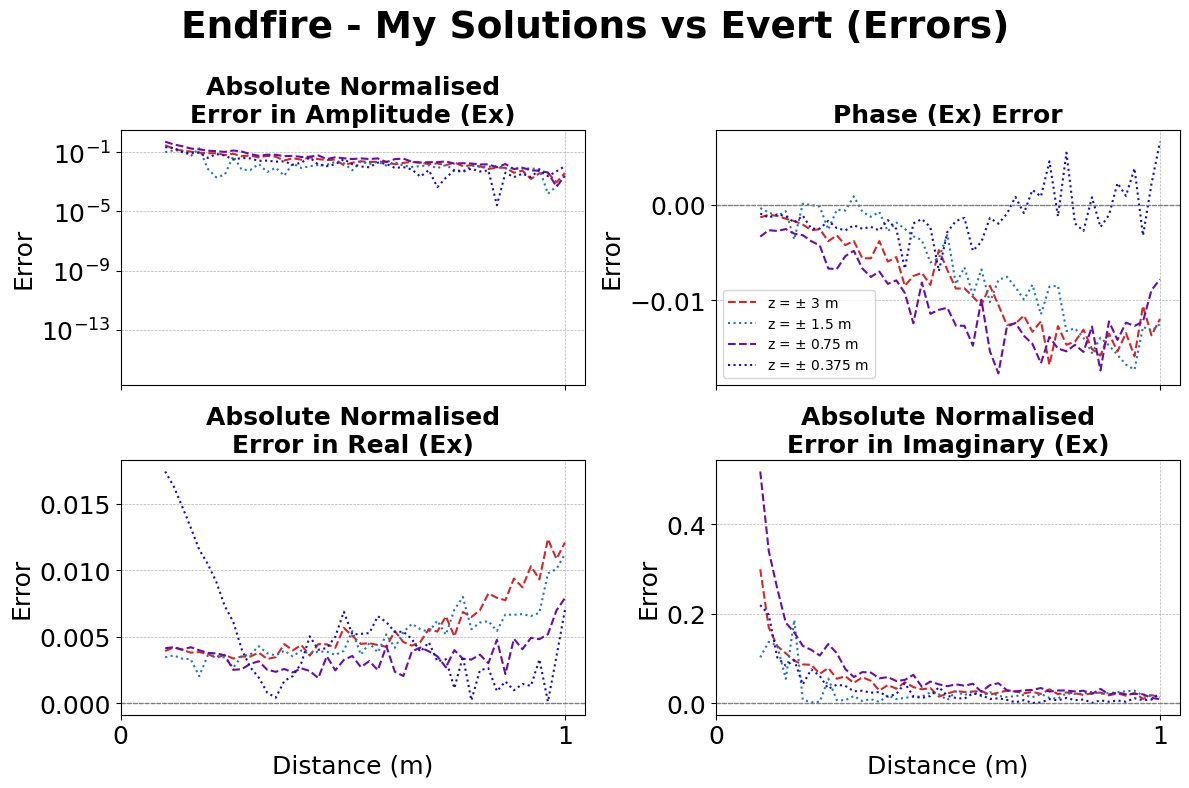

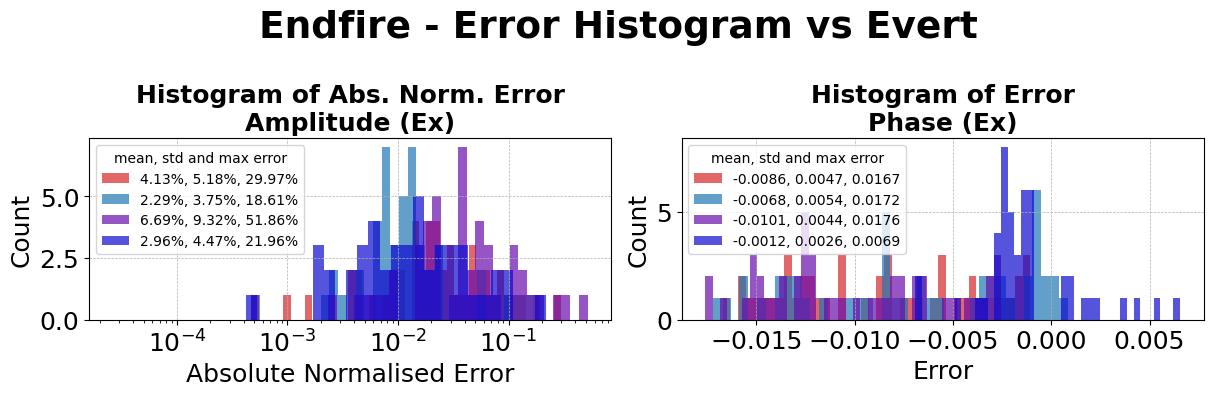

In [3]:
analytical_file = os.path.join(analytical_folder, "Exx_single_freq_air_100MHz_NR.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_evert = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Evert'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Evert'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Evert')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

electric_file = os.path.join(base_folder, "out_WA_l2_PML_l1xy_l1z", "electric_fields_receiver_line.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l2_PML_l1xy_l2z", "electric_fields_receiver_line.txt")
e_data_elfe_2 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l2_PML_l1xy_l4z", "electric_fields_receiver_line.txt")
e_data_elfe_3 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l2_PML_l1xy_l8z", "electric_fields_receiver_line.txt")
e_data_elfe_4 = np.loadtxt(electric_file)

e_data_elfe_all = [e_data_elfe_1, e_data_elfe_2, e_data_elfe_3, e_data_elfe_4]

labels = [
    r'z = $\pm$ 3 m',
    r'z = $\pm$ 1.5 m',
    r'z = $\pm$ 0.75 m',
    r'z = $\pm$ 0.375 m'
    ]

# Allow custom number of receivers for each data set
num_rec_ef_list = [48] * len(e_data_elfe_all)
num_rec_bs_list = [0] * len(e_data_elfe_all)
num_rec_ob_list = [0] * len(e_data_elfe_all)

dataset_elfe_4 = []
for i, e_data_elfe in enumerate(e_data_elfe_all):
    num_rec_ef = num_rec_ef_list[i]

    rec_x_elfe = e_data_elfe[:, 0]
    rec_y_elfe = e_data_elfe[:, 1]
    real_Ex_elfe = e_data_elfe[:, 4]
    imag_Ex_elfe = e_data_elfe[:, 5]
    abs_Ex_elfe = np.abs(real_Ex_elfe + 1j * imag_Ex_elfe)
    phase_Ex_elfe = np.angle(real_Ex_elfe + 1j * imag_Ex_elfe)

    # Endfire
    i_rx_ef = 0
    abs_ef = abs_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    phase_ef = phase_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    real_ef = real_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    imag_ef = imag_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    r_ef = rec_x_elfe[i_rx_ef:i_rx_ef + num_rec_ef]

    dataset_elfe_4.append((abs_ef, phase_ef, real_ef, imag_ef, 'Endfire', r_ef, labels[i]))

# Use datasets from Evert, empymod, and elfe for Endfire
datasets_4 = [ds for ds in dataset_evert if ds[4] == 'Endfire']
datasets_4 += dataset_elfe_4

font_suptitle = 27
font_label = 18
font_tick = 18
font_legend = 10
mark_size = 2

# Style options
colors = ['#000000', '#d62728',  '#1f77b4', '#6a0dad', "#0e0ace", "#ff00b3"]
linestyles = ['-', '--', ':', '--', ':', '--', ':']
markers = ['', 'o', 's', 'v', 'X', 'D', 'P']

# Style options for different data origins
origin_styles = {
    'Evert': {'color': colors[0], 'linestyle': linestyles[0], 'marker': markers[0]},
    labels[0]: {'color': colors[1], 'linestyle': linestyles[1], 'marker': ''},
    labels[1]: {'color': colors[2], 'linestyle': linestyles[2], 'marker': ''},
    labels[2]: {'color': colors[3], 'linestyle': linestyles[3], 'marker': ''},
    labels[3]: {'color': colors[4], 'linestyle': linestyles[4], 'marker': ''},
}

normal_lw = 2.0
orientation = 'Endfire'
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for j, (title, ylabel) in enumerate(quantities):
    ax = axes[j // 2, j % 2]
    for ds in datasets_4:
        amp, phase, real, imag, label, axis, source = ds
        style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})
        plot_label = source
        data = [amp, phase, real, imag][j]
        lw = normal_lw * 1.5 if source in ['Evert', 'empymod - 2001 DLF'] else normal_lw * 0.75
        if j == 0:
            ax.semilogy(axis, data, label=plot_label, color=style['color'],
                        linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=mark_size)
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        else:
            ax.plot(axis, data, label=plot_label, color=style['color'],
                    linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=mark_size)
            ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_title(title, fontsize=font_label, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=font_label)
    if j // 2 == 1:
        ax.set_xlabel('Distance (m)', fontsize=font_label)
    if axis.size > 0:
        xticks = np.arange(np.floor(axis.min() * 2) / 2, np.ceil(axis.max() * 2) / 2 + 0.01, 1)
        ax.set_xticks(xticks)
    ax.tick_params(axis='both', which='major', labelsize=font_tick)
    if j == 3:
        ax.legend(fontsize=font_legend, loc='upper right')
fig.suptitle(f"{orientation} - Half-Space ($\\varepsilon_r=4, \\sigma=1e\\text{{-}}4$)", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fname = f"2_decays_comparison_{orientation.lower()}.png"
plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
plt.show()


# Helper function to compute errors with interpolation only if radii differ
def compute_errors_with_interp(ref, elfe):
    errors = []
    for idx in range(4):  # amp, phase, real, imag
        ref_data = ref[idx]
        elfe_data = elfe[idx]
        ref_r = ref[5]
        elfe_r = elfe[5]
        # Interpolate reference data if radii do not match
        if len(ref_r) != len(elfe_r) or not np.allclose(ref_r, elfe_r):
            ref_data_interp = np.interp(elfe_r, ref_r, ref_data)
        else:
            ref_data_interp = ref_data
        if idx in [0, 2, 3]:
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(elfe_data - ref_data_interp) / np.abs(ref_data_interp)
                err[~np.isfinite(err)] = np.nan
        else:
            err = elfe_data - ref_data_interp
        errors.append(err)
    errors.append(elfe[5])
    return tuple(errors)

# Only plot Endfire orientation
orientation = 'Endfire'

# Select only Endfire datasets from elfe
elfe_endfire = [ds for ds in dataset_elfe_4 if ds[4] == orientation]

# Plot errors vs Evert
fig_evert, axes_evert = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ds in elfe_endfire:
    amp, phase, real, imag, _, axis, source = ds
    style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})
    lw = normal_lw * 0.75

    amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert, r_err_evert = compute_errors_with_interp(dataset_evert[0], ds)
    err_data_evert = [amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert]

    for k, ax in enumerate(axes_evert.flat):
        # Plot error curves
        ax.plot(r_err_evert, err_data_evert[k],
                label=source,
                color=style['color'],
                linestyle=style['linestyle'],
                marker=style['marker'],
                linewidth=lw, markersize=mark_size)
        ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
        ax.grid(True, linestyle='--', linewidth=0.5)
        if k == 0:
            ax.set_yscale('log')
        title_base = quantities[k][0]
        if k in [0, 2, 3]:
            ax.set_title(f"Absolute Normalised\nError in {title_base}",
                         fontsize=font_label, fontweight='bold')
        else:
            ax.set_title(f"{title_base} Error",
                         fontsize=font_label, fontweight='bold')
        if k // 2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.set_ylabel('Error', fontsize=font_label)
        if r_err_evert.size:
            start = np.floor(r_err_evert.min() * 2) / 2
            stop = np.ceil(r_err_evert.max() * 2) / 2 + 0.01
            ax.set_xticks(np.arange(start, stop, 1.0))
        ax.tick_params(axis='both', which='major', labelsize=font_tick)

axes_evert[0, 1].legend(fontsize=font_legend, loc='best')
fig_evert.suptitle(f"{orientation} - My Solutions vs Evert (Errors)",
                   fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
fname_evert = f"2_elfe_vs_evert_{orientation.lower()}_error.png"
plt.savefig(os.path.join(postprocess_folder, fname_evert), dpi=300)
plt.show()

# Plot histogram of errors for each quantity (amp, phase) vs Evert
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(12, 4))
for ds in elfe_endfire:
    amp, phase, real, imag, _, axis, source = ds
    style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})

    amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert, r_err_evert = compute_errors_with_interp(dataset_evert[0], ds)
    err_data_evert = [amp_err_evert, phase_err_evert]

    for k, ax in enumerate(axes_hist.flat):
        # Remove NaNs/Infs for histogram
        err_flat = err_data_evert[k][np.isfinite(err_data_evert[k])]
        # Use log for amplitude error histogram
        if k == 0:
            bins = np.logspace(np.log10(np.nanmin(err_flat[err_flat > 0])), np.log10(np.nanmax(err_flat)), 40)
            mean_val = np.nanmean(err_flat) * 100
            std_val = np.nanstd(err_flat) * 100
            max_val = np.nanmax(err_flat) * 100
            label_stats = f"{mean_val:.2f}%, {std_val:.2f}%, {max_val:.2f}%"
            ax.hist(err_flat, bins=bins, color=style['color'], alpha=0.7, label=label_stats)
            ax.set_xscale('log')
        else:
            mean_val = np.nanmean(err_flat)
            std_val = np.nanstd(err_flat)
            max_val = np.nanmax(np.abs(err_flat))
            label_stats = f"{mean_val:.4f}, {std_val:.4f}, {max_val:.4f}"
            ax.hist(err_flat, bins=40, color=style['color'], alpha=0.7, label=label_stats)
        title_base = quantities[k][0]
        if k == 0:
            ax.set_title(f"Histogram of Abs. Norm. Error\n{title_base}", fontsize=font_label, fontweight='bold')
            ax.set_xlabel('Absolute Normalised Error', fontsize=font_label)
        else:
            ax.set_title(f"Histogram of Error\n{title_base}", fontsize=font_label, fontweight='bold')
            ax.set_xlabel('Error', fontsize=font_label)
        ax.set_ylabel('Count', fontsize=font_label)
        legend = ax.legend(fontsize=font_legend, title="mean, std and max error")
        ax.grid(True, linestyle='--', linewidth=0.5)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)

fig_hist.suptitle(f"{orientation} - Error Histogram vs Evert", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fname_hist = f"2_elfe_vs_evert_{orientation.lower()}_error_hist.png"
plt.savefig(os.path.join(postprocess_folder, fname_hist), dpi=300)
plt.show()


## Whole-Space xy

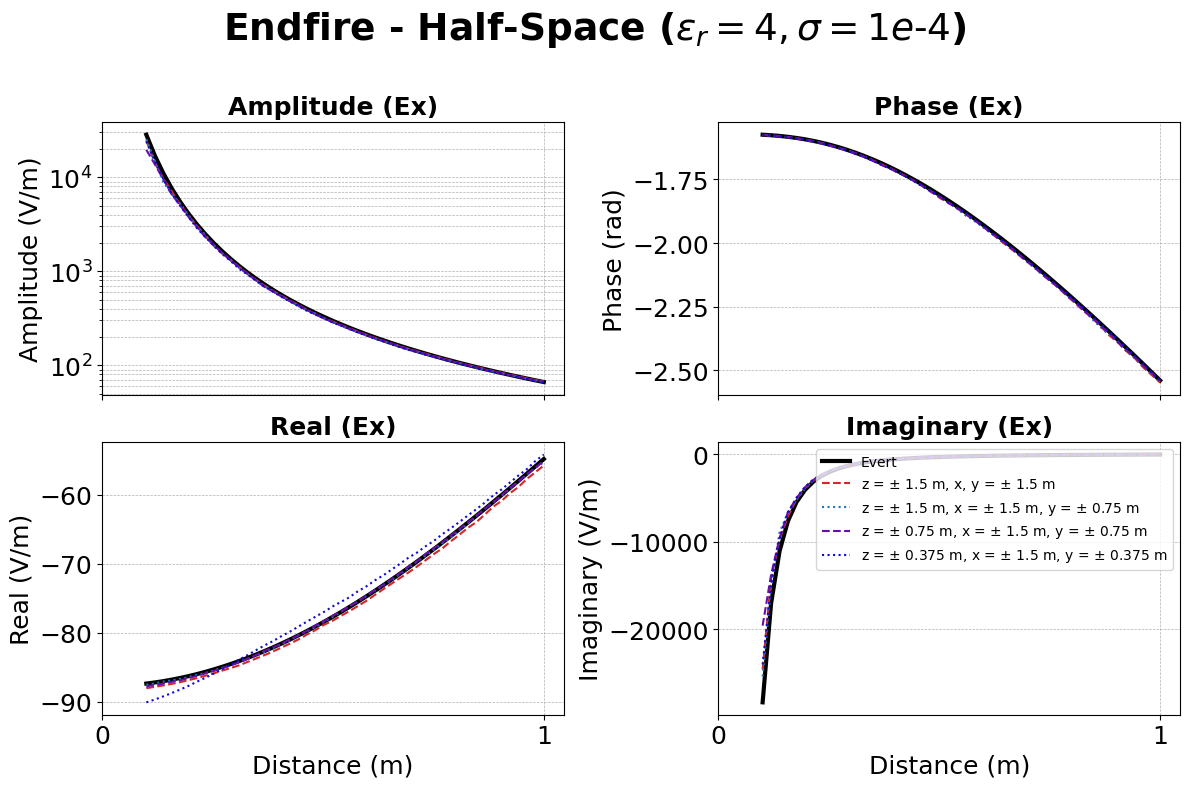

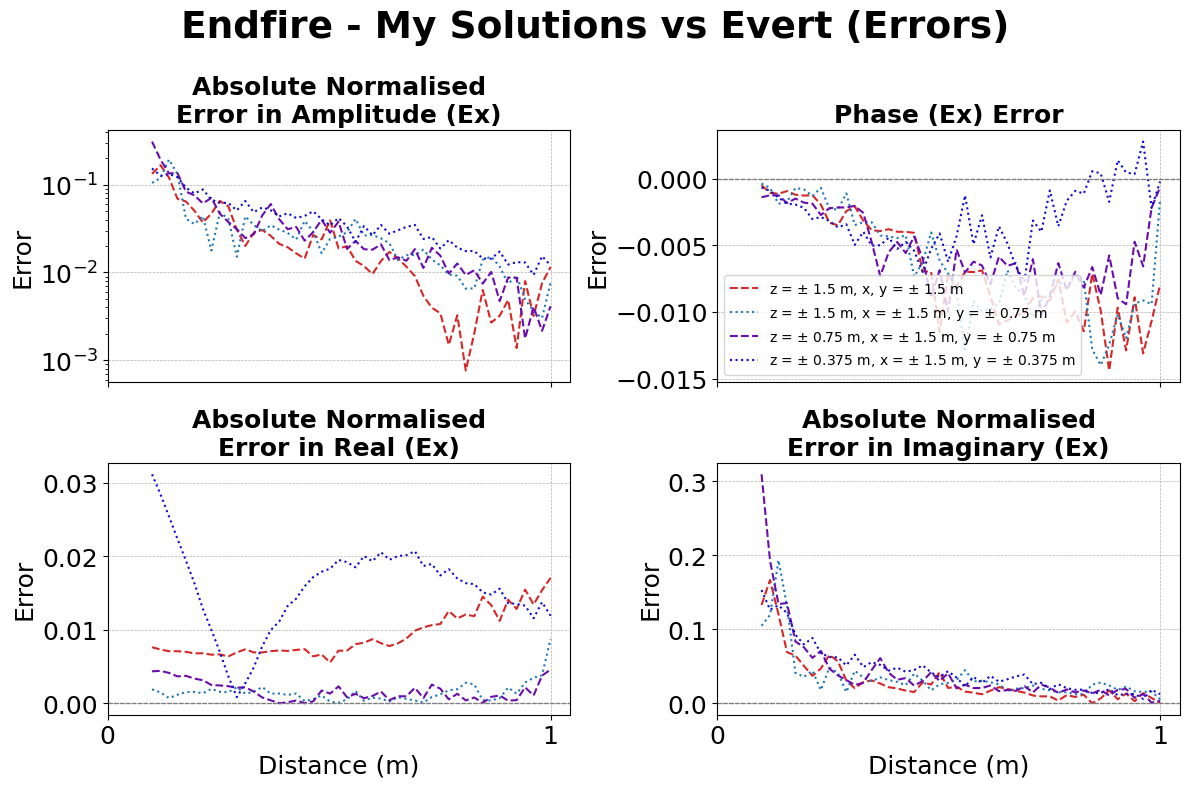

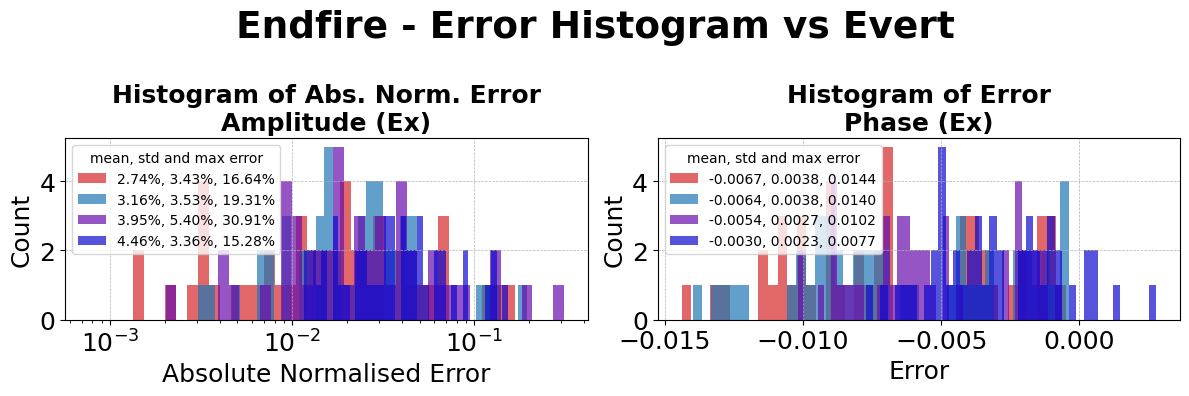

In [4]:
analytical_file = os.path.join(analytical_folder, "Exx_single_freq_air_100MHz_NR.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_evert = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Evert'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Evert'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Evert')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

electric_file = os.path.join(base_folder, "out_WA_l2_PML_l2xy_l2z", "electric_fields_receiver_line.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l2_PML_l2x_l4y_l2z", "electric_fields_receiver_line.txt")
e_data_elfe_2 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l2_PML_l2x_l4yz", "electric_fields_receiver_line.txt")
e_data_elfe_3 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l2_PML_l2x_l8yz", "electric_fields_receiver_line.txt")
e_data_elfe_4 = np.loadtxt(electric_file)

e_data_elfe_all = [e_data_elfe_1, e_data_elfe_2, e_data_elfe_3, e_data_elfe_4]

labels = [
    r'z = $\pm$ 1.5 m, x, y = $\pm$ 1.5 m',
    r'z = $\pm$ 1.5 m, x = $\pm$ 1.5 m, y = $\pm$ 0.75 m',
    r'z = $\pm$ 0.75 m, x = $\pm$ 1.5 m, y = $\pm$ 0.75 m',
    r'z = $\pm$ 0.375 m, x = $\pm$ 1.5 m, y = $\pm$ 0.375 m'
    ]

# Allow custom number of receivers for each data set
num_rec_ef_list = [48] * len(e_data_elfe_all)
num_rec_bs_list = [0] * len(e_data_elfe_all)
num_rec_ob_list = [0] * len(e_data_elfe_all)

dataset_elfe_4 = []
for i, e_data_elfe in enumerate(e_data_elfe_all):
    num_rec_ef = num_rec_ef_list[i]

    rec_x_elfe = e_data_elfe[:, 0]
    rec_y_elfe = e_data_elfe[:, 1]
    real_Ex_elfe = e_data_elfe[:, 4]
    imag_Ex_elfe = e_data_elfe[:, 5]
    abs_Ex_elfe = np.abs(real_Ex_elfe + 1j * imag_Ex_elfe)
    phase_Ex_elfe = np.angle(real_Ex_elfe + 1j * imag_Ex_elfe)

    # Endfire
    i_rx_ef = 0
    abs_ef = abs_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    phase_ef = phase_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    real_ef = real_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    imag_ef = imag_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    r_ef = rec_x_elfe[i_rx_ef:i_rx_ef + num_rec_ef]

    dataset_elfe_4.append((abs_ef, phase_ef, real_ef, imag_ef, 'Endfire', r_ef, labels[i]))

# Use datasets from Evert, empymod, and elfe for Endfire
datasets_4 = [ds for ds in dataset_evert if ds[4] == 'Endfire']
datasets_4 += dataset_elfe_4

font_suptitle = 27
font_label = 18
font_tick = 18
font_legend = 10
mark_size = 2

# Style options
colors = ['#000000', '#d62728',  '#1f77b4', '#6a0dad', "#0e0ace", "#ff00b3"]
linestyles = ['-', '--', ':', '--', ':', '--', ':']
markers = ['', 'o', 's', 'v', 'X', 'D', 'P']

# Style options for different data origins
origin_styles = {
    'Evert': {'color': colors[0], 'linestyle': linestyles[0], 'marker': markers[0]},
    labels[0]: {'color': colors[1], 'linestyle': linestyles[1], 'marker': ''},
    labels[1]: {'color': colors[2], 'linestyle': linestyles[2], 'marker': ''},
    labels[2]: {'color': colors[3], 'linestyle': linestyles[3], 'marker': ''},
    labels[3]: {'color': colors[4], 'linestyle': linestyles[4], 'marker': ''},
}

normal_lw = 2.0
orientation = 'Endfire'
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for j, (title, ylabel) in enumerate(quantities):
    ax = axes[j // 2, j % 2]
    for ds in datasets_4:
        amp, phase, real, imag, label, axis, source = ds
        style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})
        plot_label = source
        data = [amp, phase, real, imag][j]
        lw = normal_lw * 1.5 if source in ['Evert', 'empymod - 2001 DLF'] else normal_lw * 0.75
        if j == 0:
            ax.semilogy(axis, data, label=plot_label, color=style['color'],
                        linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=mark_size)
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        else:
            ax.plot(axis, data, label=plot_label, color=style['color'],
                    linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=mark_size)
            ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_title(title, fontsize=font_label, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=font_label)
    if j // 2 == 1:
        ax.set_xlabel('Distance (m)', fontsize=font_label)
    if axis.size > 0:
        xticks = np.arange(np.floor(axis.min() * 2) / 2, np.ceil(axis.max() * 2) / 2 + 0.01, 1)
        ax.set_xticks(xticks)
    ax.tick_params(axis='both', which='major', labelsize=font_tick)
    if j == 3:
        ax.legend(fontsize=font_legend, loc='upper right')
fig.suptitle(f"{orientation} - Half-Space ($\\varepsilon_r=4, \\sigma=1e\\text{{-}}4$)", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fname = f"3_decays_comparison_{orientation.lower()}.png"
plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
plt.show()


# Helper function to compute errors with interpolation only if radii differ
def compute_errors_with_interp(ref, elfe):
    errors = []
    for idx in range(4):  # amp, phase, real, imag
        ref_data = ref[idx]
        elfe_data = elfe[idx]
        ref_r = ref[5]
        elfe_r = elfe[5]
        # Interpolate reference data if radii do not match
        if len(ref_r) != len(elfe_r) or not np.allclose(ref_r, elfe_r):
            ref_data_interp = np.interp(elfe_r, ref_r, ref_data)
        else:
            ref_data_interp = ref_data
        if idx in [0, 2, 3]:
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(elfe_data - ref_data_interp) / np.abs(ref_data_interp)
                err[~np.isfinite(err)] = np.nan
        else:
            err = elfe_data - ref_data_interp
        errors.append(err)
    errors.append(elfe[5])
    return tuple(errors)

# Only plot Endfire orientation
orientation = 'Endfire'

# Select only Endfire datasets from elfe
elfe_endfire = [ds for ds in dataset_elfe_4 if ds[4] == orientation]

# Plot errors vs Evert
fig_evert, axes_evert = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ds in elfe_endfire:
    amp, phase, real, imag, _, axis, source = ds
    style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})
    lw = normal_lw * 0.75

    amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert, r_err_evert = compute_errors_with_interp(dataset_evert[0], ds)
    err_data_evert = [amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert]

    for k, ax in enumerate(axes_evert.flat):
        # Plot error curves
        ax.plot(r_err_evert, err_data_evert[k],
                label=source,
                color=style['color'],
                linestyle=style['linestyle'],
                marker=style['marker'],
                linewidth=lw, markersize=mark_size)
        ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
        ax.grid(True, linestyle='--', linewidth=0.5)
        if k == 0:
            ax.set_yscale('log')
        title_base = quantities[k][0]
        if k in [0, 2, 3]:
            ax.set_title(f"Absolute Normalised\nError in {title_base}",
                         fontsize=font_label, fontweight='bold')
        else:
            ax.set_title(f"{title_base} Error",
                         fontsize=font_label, fontweight='bold')
        if k // 2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.set_ylabel('Error', fontsize=font_label)
        if r_err_evert.size:
            start = np.floor(r_err_evert.min() * 2) / 2
            stop = np.ceil(r_err_evert.max() * 2) / 2 + 0.01
            ax.set_xticks(np.arange(start, stop, 1.0))
        ax.tick_params(axis='both', which='major', labelsize=font_tick)

axes_evert[0, 1].legend(fontsize=font_legend, loc='best')
fig_evert.suptitle(f"{orientation} - My Solutions vs Evert (Errors)",
                   fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
fname_evert = f"3_elfe_vs_evert_{orientation.lower()}_error.png"
plt.savefig(os.path.join(postprocess_folder, fname_evert), dpi=300)
plt.show()

# Plot histogram of errors for each quantity (amp, phase) vs Evert
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(12, 4))
for ds in elfe_endfire:
    amp, phase, real, imag, _, axis, source = ds
    style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})

    amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert, r_err_evert = compute_errors_with_interp(dataset_evert[0], ds)
    err_data_evert = [amp_err_evert, phase_err_evert]

    for k, ax in enumerate(axes_hist.flat):
        # Remove NaNs/Infs for histogram
        err_flat = err_data_evert[k][np.isfinite(err_data_evert[k])]
        # Use log for amplitude error histogram
        if k == 0:
            bins = np.logspace(np.log10(np.nanmin(err_flat[err_flat > 0])), np.log10(np.nanmax(err_flat)), 40)
            mean_val = np.nanmean(err_flat) * 100
            std_val = np.nanstd(err_flat) * 100
            max_val = np.nanmax(err_flat) * 100
            label_stats = f"{mean_val:.2f}%, {std_val:.2f}%, {max_val:.2f}%"
            ax.hist(err_flat, bins=bins, color=style['color'], alpha=0.7, label=label_stats)
            ax.set_xscale('log')
        else:
            mean_val = np.nanmean(err_flat)
            std_val = np.nanstd(err_flat)
            max_val = np.nanmax(np.abs(err_flat))
            label_stats = f"{mean_val:.4f}, {std_val:.4f}, {max_val:.4f}"
            ax.hist(err_flat, bins=40, color=style['color'], alpha=0.7, label=label_stats)
        title_base = quantities[k][0]
        if k == 0:
            ax.set_title(f"Histogram of Abs. Norm. Error\n{title_base}", fontsize=font_label, fontweight='bold')
            ax.set_xlabel('Absolute Normalised Error', fontsize=font_label)
        else:
            ax.set_title(f"Histogram of Error\n{title_base}", fontsize=font_label, fontweight='bold')
            ax.set_xlabel('Error', fontsize=font_label)
        ax.set_ylabel('Count', fontsize=font_label)
        legend = ax.legend(fontsize=font_legend, title="mean, std and max error")
        ax.grid(True, linestyle='--', linewidth=0.5)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)

fig_hist.suptitle(f"{orientation} - Error Histogram vs Evert", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fname_hist = f"3_elfe_vs_evert_{orientation.lower()}_error_hist.png"
plt.savefig(os.path.join(postprocess_folder, fname_hist), dpi=300)
plt.show()


## PML Thickness: l2xyz

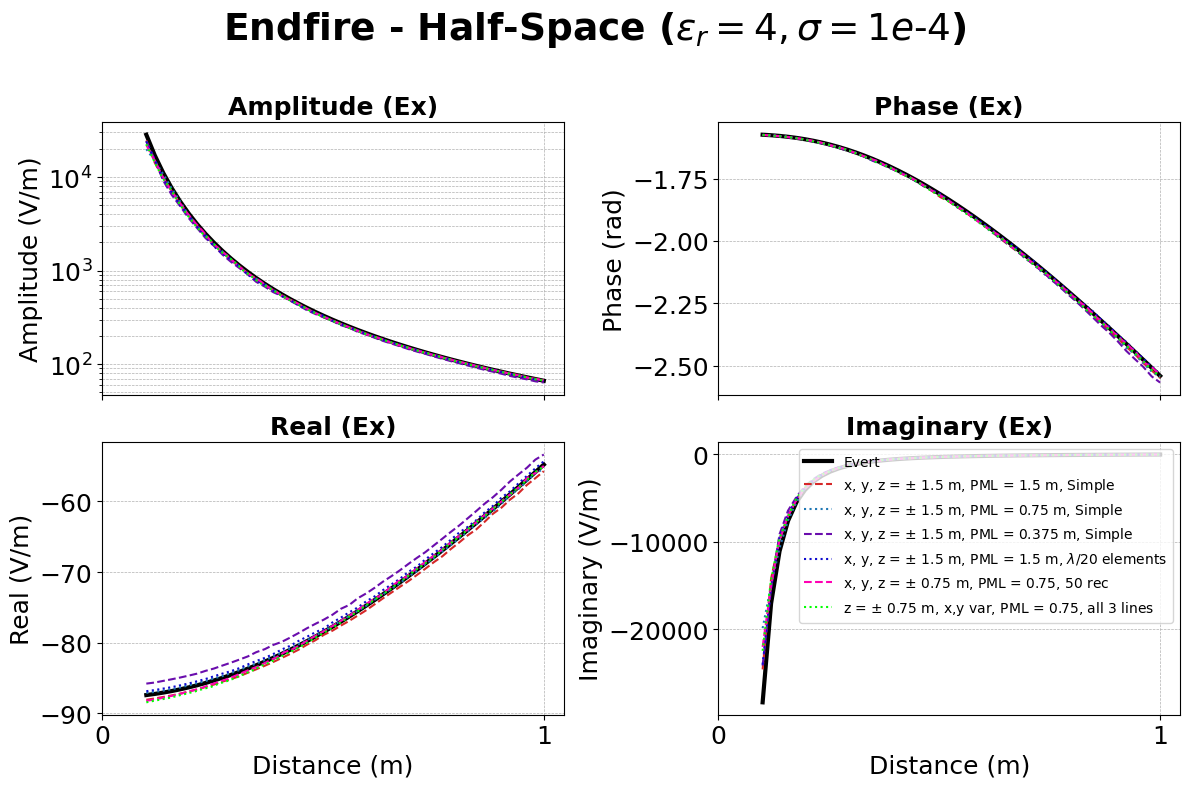

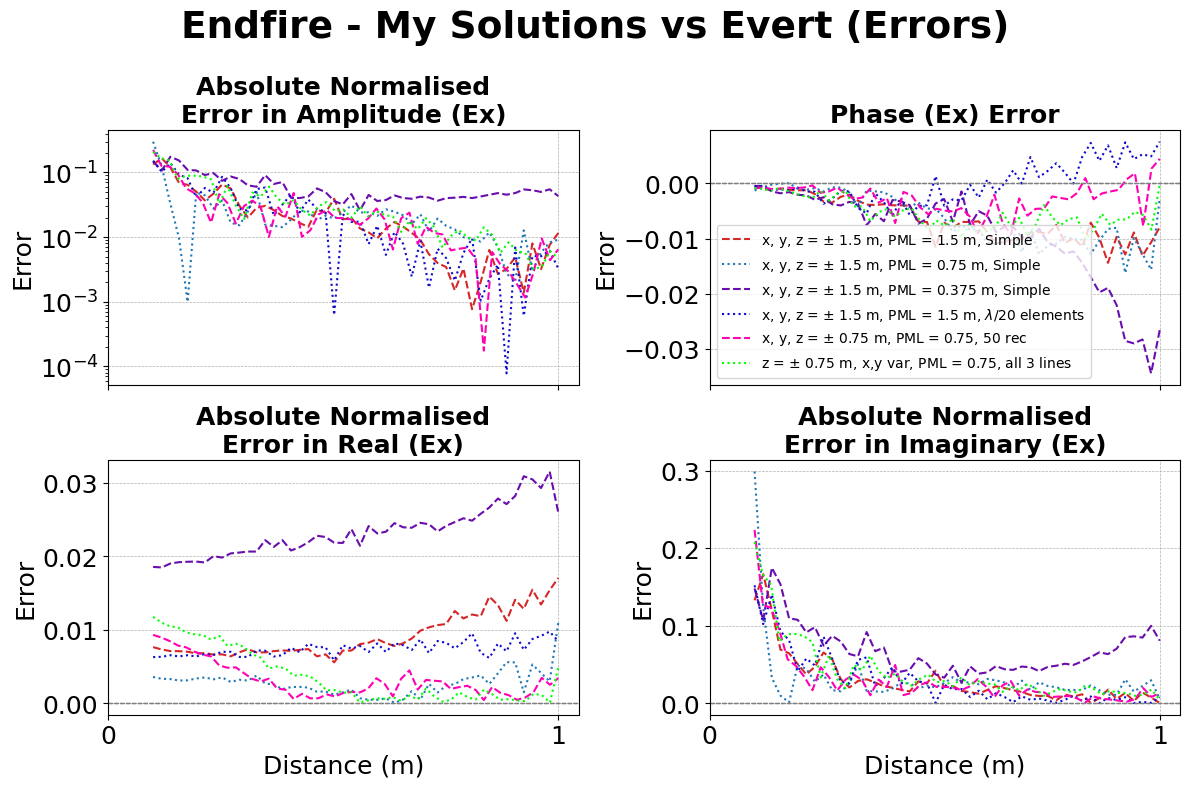

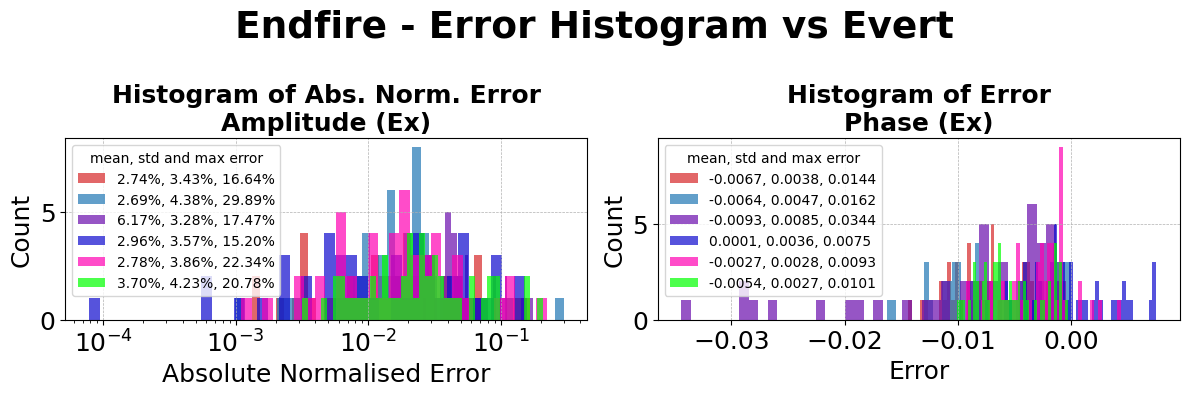

In [9]:
analytical_file = os.path.join(analytical_folder, "Exx_single_freq_air_100MHz_NR.csv")
analytical_lines = np.loadtxt(analytical_file, delimiter=',', skiprows=1)

r = analytical_lines[:, 0]

# Endfire
abs_endfire = analytical_lines[:, 1]
real_endfire = analytical_lines[:, 3]
imag_endfire = analytical_lines[:, 4]
phase_endfire = np.arctan2(imag_endfire, real_endfire)

# Broadside
abs_broadside = analytical_lines[:, 5]
real_broadside = -1*analytical_lines[:, 7]
imag_broadside = -1*analytical_lines[:, 8]
phase_broadside = np.arctan2(imag_broadside, real_broadside)

# Oblique
abs_45deg = analytical_lines[:, 9]
real_45deg = -1*analytical_lines[:, 11]
imag_45deg = -1*analytical_lines[:, 12]
phase_45deg = np.arctan2(imag_45deg, real_45deg)

dataset_evert = [
    (abs_endfire, phase_endfire, real_endfire, imag_endfire, 'Endfire', r, 'Evert'),
    (abs_broadside, phase_broadside, real_broadside, imag_broadside, 'Broadside', r, 'Evert'),
    (abs_45deg, phase_45deg, real_45deg, imag_45deg, 'Oblique', r, 'Evert')
]
quantities = [
    ('Amplitude (Ex)', 'Amplitude (V/m)'),
    ('Phase (Ex)', 'Phase (rad)'),
    ('Real (Ex)', 'Real (V/m)'),
    ('Imaginary (Ex)', 'Imaginary (V/m)')
]

electric_file = os.path.join(base_folder, "out_WA_l2_PML_l2xy_l2z", "electric_fields_receiver_line.txt")
e_data_elfe_1 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l4_PML_l2xyz", "electric_fields_receiver_line.txt")
e_data_elfe_2 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l8_PML_l2xyz", "electric_fields_receiver_line.txt")
e_data_elfe_3 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l8_PML_l2xyz_l20", "electric_fields_receiver_line.txt")
e_data_elfe_4 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l4_PML_l4xyz_12r", "electric_fields_receiver_line.txt")
e_data_elfe_5 = np.loadtxt(electric_file)

electric_file = os.path.join(base_folder, "out_WA_l4_PML_12xy_l4z_all", "electric_fields_receiver_line.txt")
e_data_elfe_6 = np.loadtxt(electric_file)


e_data_elfe_all = [e_data_elfe_1, e_data_elfe_2, e_data_elfe_3, e_data_elfe_4, e_data_elfe_5, e_data_elfe_6]

labels = [
    r'x, y, z = $\pm$ 1.5 m, PML = 1.5 m, Simple',
    r'x, y, z = $\pm$ 1.5 m, PML = 0.75 m, Simple',
    r'x, y, z = $\pm$ 1.5 m, PML = 0.375 m, Simple',
    r'x, y, z = $\pm$ 1.5 m, PML = 1.5 m, $\lambda$/20 elements',
    r'x, y, z = $\pm$ 0.75 m, PML = 0.75, 50 rec',
    r'z = $\pm$ 0.75 m, x,y var, PML = 0.75, all 3 lines'
    ]

# Allow custom number of receivers for each data set
num_rec_ef_list = [48, 48, 48, 48, 50, 50]
num_rec_bs_list = [0, 0, 0, 0, 0, 50]
num_rec_ob_list = [0, 0, 0, 0, 0, 50]

dataset_elfe_4 = []
for i, e_data_elfe in enumerate(e_data_elfe_all):
    num_rec_ef = num_rec_ef_list[i]

    rec_x_elfe = e_data_elfe[:, 0]
    rec_y_elfe = e_data_elfe[:, 1]
    real_Ex_elfe = e_data_elfe[:, 4]
    imag_Ex_elfe = e_data_elfe[:, 5]
    abs_Ex_elfe = np.abs(real_Ex_elfe + 1j * imag_Ex_elfe)
    phase_Ex_elfe = np.angle(real_Ex_elfe + 1j * imag_Ex_elfe)

    # Endfire
    i_rx_ef = 0
    abs_ef = abs_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    phase_ef = phase_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    real_ef = real_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    imag_ef = imag_Ex_elfe[i_rx_ef:i_rx_ef + num_rec_ef]
    r_ef = rec_x_elfe[i_rx_ef:i_rx_ef + num_rec_ef]

    dataset_elfe_4.append((abs_ef, phase_ef, real_ef, imag_ef, 'Endfire', r_ef, labels[i]))

# Use datasets from Evert, empymod, and elfe for Endfire
datasets_4 = [ds for ds in dataset_evert if ds[4] == 'Endfire']
datasets_4 += dataset_elfe_4

font_suptitle = 27
font_label = 18
font_tick = 18
font_legend = 10
mark_size = 2

# Style options
colors = ['#000000', '#d62728',  '#1f77b4', '#6a0dad', "#0e0ace", "#ff00b3", "#00ff00"]
linestyles = ['-', '--', ':', '--', ':', '--', ':', '--']
markers = ['', 'o', 's', 'v', 'X', 'D', 'P']

# Style options for different data origins
origin_styles = {
    'Evert': {'color': colors[0], 'linestyle': linestyles[0], 'marker': markers[0]},
    labels[0]: {'color': colors[1], 'linestyle': linestyles[1], 'marker': ''},
    labels[1]: {'color': colors[2], 'linestyle': linestyles[2], 'marker': ''},
    labels[2]: {'color': colors[3], 'linestyle': linestyles[3], 'marker': ''},
    labels[3]: {'color': colors[4], 'linestyle': linestyles[4], 'marker': ''},
    labels[4]: {'color': colors[5], 'linestyle': linestyles[5], 'marker': ''},
    labels[5]: {'color': colors[6], 'linestyle': linestyles[6], 'marker': ''},
}

normal_lw = 2.0
orientation = 'Endfire'
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for j, (title, ylabel) in enumerate(quantities):
    ax = axes[j // 2, j % 2]
    for ds in datasets_4:
        amp, phase, real, imag, label, axis, source = ds
        style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})
        plot_label = source
        data = [amp, phase, real, imag][j]
        lw = normal_lw * 1.5 if source in ['Evert', 'empymod - 2001 DLF'] else normal_lw * 0.75
        if j == 0:
            ax.semilogy(axis, data, label=plot_label, color=style['color'],
                        linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=mark_size)
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        else:
            ax.plot(axis, data, label=plot_label, color=style['color'],
                    linestyle=style['linestyle'], marker=style['marker'], linewidth=lw, markersize=mark_size)
            ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_title(title, fontsize=font_label, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=font_label)
    if j // 2 == 1:
        ax.set_xlabel('Distance (m)', fontsize=font_label)
    if axis.size > 0:
        xticks = np.arange(np.floor(axis.min() * 2) / 2, np.ceil(axis.max() * 2) / 2 + 0.01, 1)
        ax.set_xticks(xticks)
    ax.tick_params(axis='both', which='major', labelsize=font_tick)
    if j == 3:
        ax.legend(fontsize=font_legend, loc='upper right')
fig.suptitle(f"{orientation} - Half-Space ($\\varepsilon_r=4, \\sigma=1e\\text{{-}}4$)", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fname = f"4_decays_comparison_{orientation.lower()}.png"
plt.savefig(os.path.join(postprocess_folder, fname), dpi=300)
plt.show()


# Helper function to compute errors with interpolation only if radii differ
def compute_errors_with_interp(ref, elfe):
    errors = []
    for idx in range(4):  # amp, phase, real, imag
        ref_data = ref[idx]
        elfe_data = elfe[idx]
        ref_r = ref[5]
        elfe_r = elfe[5]
        # Interpolate reference data if radii do not match
        if len(ref_r) != len(elfe_r) or not np.allclose(ref_r, elfe_r):
            ref_data_interp = np.interp(elfe_r, ref_r, ref_data)
        else:
            ref_data_interp = ref_data
        if idx in [0, 2, 3]:
            with np.errstate(divide='ignore', invalid='ignore'):
                err = np.abs(elfe_data - ref_data_interp) / np.abs(ref_data_interp)
                err[~np.isfinite(err)] = np.nan
        else:
            err = elfe_data - ref_data_interp
        errors.append(err)
    errors.append(elfe[5])
    return tuple(errors)

# Only plot Endfire orientation
orientation = 'Endfire'

# Select only Endfire datasets from elfe
elfe_endfire = [ds for ds in dataset_elfe_4 if ds[4] == orientation]

# Plot errors vs Evert
fig_evert, axes_evert = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ds in elfe_endfire:
    amp, phase, real, imag, _, axis, source = ds
    style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})
    lw = normal_lw * 0.75

    amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert, r_err_evert = compute_errors_with_interp(dataset_evert[0], ds)
    err_data_evert = [amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert]

    for k, ax in enumerate(axes_evert.flat):
        # Plot error curves
        ax.plot(r_err_evert, err_data_evert[k],
                label=source,
                color=style['color'],
                linestyle=style['linestyle'],
                marker=style['marker'],
                linewidth=lw, markersize=mark_size)
        ax.axhline(0, linestyle='--', linewidth=0.8, color='gray')
        ax.grid(True, linestyle='--', linewidth=0.5)
        if k == 0:
            ax.set_yscale('log')
        title_base = quantities[k][0]
        if k in [0, 2, 3]:
            ax.set_title(f"Absolute Normalised\nError in {title_base}",
                         fontsize=font_label, fontweight='bold')
        else:
            ax.set_title(f"{title_base} Error",
                         fontsize=font_label, fontweight='bold')
        if k // 2 == 1:
            ax.set_xlabel('Distance (m)', fontsize=font_label)
        ax.set_ylabel('Error', fontsize=font_label)
        if r_err_evert.size:
            start = np.floor(r_err_evert.min() * 2) / 2
            stop = np.ceil(r_err_evert.max() * 2) / 2 + 0.01
            ax.set_xticks(np.arange(start, stop, 1.0))
        ax.tick_params(axis='both', which='major', labelsize=font_tick)

axes_evert[0, 1].legend(fontsize=font_legend, loc='best')
fig_evert.suptitle(f"{orientation} - My Solutions vs Evert (Errors)",
                   fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
fname_evert = f"4_elfe_vs_evert_{orientation.lower()}_error.png"
plt.savefig(os.path.join(postprocess_folder, fname_evert), dpi=300)
plt.show()

# Plot histogram of errors for each quantity (amp, phase) vs Evert
fig_hist, axes_hist = plt.subplots(1, 2, figsize=(12, 4))
for ds in elfe_endfire:
    amp, phase, real, imag, _, axis, source = ds
    style = origin_styles.get(source, {'color': 'gray', 'linestyle': '-', 'marker': ''})

    amp_err_evert, phase_err_evert, real_err_evert, imag_err_evert, r_err_evert = compute_errors_with_interp(dataset_evert[0], ds)
    err_data_evert = [amp_err_evert, phase_err_evert]

    for k, ax in enumerate(axes_hist.flat):
        # Remove NaNs/Infs for histogram
        err_flat = err_data_evert[k][np.isfinite(err_data_evert[k])]
        # Use log for amplitude error histogram
        if k == 0:
            bins = np.logspace(np.log10(np.nanmin(err_flat[err_flat > 0])), np.log10(np.nanmax(err_flat)), 40)
            mean_val = np.nanmean(err_flat) * 100
            std_val = np.nanstd(err_flat) * 100
            max_val = np.nanmax(err_flat) * 100
            label_stats = f"{mean_val:.2f}%, {std_val:.2f}%, {max_val:.2f}%"
            ax.hist(err_flat, bins=bins, color=style['color'], alpha=0.7, label=label_stats)
            ax.set_xscale('log')
        else:
            mean_val = np.nanmean(err_flat)
            std_val = np.nanstd(err_flat)
            max_val = np.nanmax(np.abs(err_flat))
            label_stats = f"{mean_val:.4f}, {std_val:.4f}, {max_val:.4f}"
            ax.hist(err_flat, bins=40, color=style['color'], alpha=0.7, label=label_stats)
        title_base = quantities[k][0]
        if k == 0:
            ax.set_title(f"Histogram of Abs. Norm. Error\n{title_base}", fontsize=font_label, fontweight='bold')
            ax.set_xlabel('Absolute Normalised Error', fontsize=font_label)
        else:
            ax.set_title(f"Histogram of Error\n{title_base}", fontsize=font_label, fontweight='bold')
            ax.set_xlabel('Error', fontsize=font_label)
        ax.set_ylabel('Count', fontsize=font_label)
        legend = ax.legend(fontsize=font_legend, title="mean, std and max error")
        ax.grid(True, linestyle='--', linewidth=0.5)
        ax.tick_params(axis='both', which='major', labelsize=font_tick)

fig_hist.suptitle(f"{orientation} - Error Histogram vs Evert", fontsize=font_suptitle, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
fname_hist = f"4_elfe_vs_evert_{orientation.lower()}_error_hist.png"
plt.savefig(os.path.join(postprocess_folder, fname_hist), dpi=300)
plt.show()
